In [ ]:
import jax
import jax.numpy as jnp
import diffrax
from CoolProp.CoolProp import PropsSI
from diffrax import PIDController

class Cryogen:
    def __init__(self, fluid='ammonia', P=100000):
        self.fluid = fluid
        self.P = P
        self.T_sat = PropsSI('T', 'P', P, 'Q', 0, fluid)
        self.h_L = PropsSI('H', 'P', P, 'Q', 0, fluid)
        self.h_V = PropsSI('H', 'P', P, 'Q', 1, fluid)
        self.rho_L = PropsSI('D', 'P', P, 'Q', 0, fluid)
        self.rho_V = PropsSI('D', 'P', P, 'Q', 1, fluid)
        self.k_V = PropsSI('L', 'P', P, 'Q', 1, fluid)
        self.cp_V = PropsSI('C', 'P', P, 'Q', 1, fluid)

class Tank:
    def __init__(self, d_i, d_o, V, LF=0.95, cryogen=None):
        self.d_i = d_i
        self.d_o = d_o
        self.V = V
        self.LF = LF
        self.cryogen = cryogen or Cryogen()
        self.z_grid = jnp.linspace(0, 1, 50)
        self.time_interval = 3600
        self.U_L = 0.08
        self.U_V = 0.08
        self.T_air = 298.15
        self.Q_b_fixed = None
        self.Q_roof = 0
        self.eta_w = 0.7

    
    def A_T(self):
        return jnp.pi * self.d_i ** 2 / 4

    def l(self):
        return self.V / self.A_T()

    def Q_L_in(self):
        A_L = jnp.pi * self.d_o * self.l() * self.LF
        return self.U_L * A_L * (self.T_air - self.cryogen.T_sat)

    def Q_wi(self, Tv_avg):
        A_V = jnp.pi * self.d_o * self.l() * (1 - self.LF)
        return self.U_V * A_V * self.eta_w * (self.T_air - Tv_avg)

    def Q_b(self):
        if self.Q_b_fixed is not None:
            return self.Q_b_fixed
        else:
            return self.U_L * self.A_T() * (self.T_air - self.cryogen.T_sat)

    def v_z(self):
        BL_0 = (self.Q_L_in() + self.Q_b() + self.Q_wi(self.cryogen.T_sat)) / (self.cryogen.h_V - self.cryogen.h_L)
        return 4 * BL_0 / (self.cryogen.rho_V * jnp.pi * self.d_i ** 2)

    def sys_isobaric(self, t, y, args):
        V_L = y[0]
        T_V = y[1:]
        LF = V_L / self.V
        l_dry = self.l() * (1 - LF)
        dz = (self.z_grid[1] - self.z_grid[0]) * l_dry
        n = len(self.z_grid)
        dT = jnp.zeros(n)
        dT = dT.at[1:-1].set(
            self.cryogen.k_V / (self.cryogen.rho_V * self.cryogen.cp_V) *
            (T_V[:-2] - 2 * T_V[1:-1] + T_V[2:]) / dz ** 2 -
            (self.v_z() - self.v_z() * (self.cryogen.rho_V / self.cryogen.rho_L)) *
            (T_V[1:-1] - T_V[:-2]) / dz +
            (self.cryogen.k_V / (self.cryogen.rho_V * self.cryogen.cp_V)) *
            (4 * self.U_V * self.d_o / self.d_i ** 2) *
            (self.T_air - T_V[1:-1]) * (1 - self.eta_w)
        )
        dT = dT.at[0].set(0)
        dT = dT.at[-1].set((4 * dT[-2] - dT[-3]) / 3)
        dV = -1 / self.cryogen.rho_L * (
            self.Q_L_in() + self.Q_b() + self.Q_wi(jnp.mean(T_V)) +
            self.cryogen.k_V * self.A_T() * (-3 * T_V[0] + 4 * T_V[1] - T_V[2]) / (2 * dz)
        ) / (self.cryogen.h_V - self.cryogen.h_L)
        return jnp.concatenate([jnp.array([dV]), dT])

    def evaporate(self, t_f):
        VL_0 = self.V * self.LF
        Tv_0 = jnp.ones(len(self.z_grid)) * self.cryogen.T_sat
        IC = jnp.concatenate([jnp.array([VL_0]), Tv_0])
        term = diffrax.ODETerm(self.sys_isobaric)
        solver = diffrax.Kvaerno5()
        saveat = diffrax.SaveAt(ts=jnp.arange(0, t_f + 1, self.time_interval))
        sol = diffrax.diffeqsolve(
            term,
            solver=diffrax.Kvaerno5(),
            t0=0,
            t1=t_f,
            dt0=1.0,  # valor inicial sugerido
            y0=IC,
            args=None,
            saveat=saveat,
            max_steps=100000,
            stepsize_controller=PIDController(rtol=1e-6, atol=1e-6),  # ✅ aquí el controlador
        )
        return sol


In [55]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

#V_tank = 60000 # Tank volume / m^3
V_tank = 165000 # Tank volume / m^3

a = 0.7077
d_i = ((4 * V_tank)/(jnp.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.08 # 0.08 # W/m2/K
U_V = 0.08 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 100000 # Pa

# # Initialise cryogen
cryogen = Cryogen("ammonia")

tanque = Tank(d_i, d_o, V_tank, LF)

In [56]:
sol = tanque.evaporate(3600*720)

ValueError: Terms are not compatible with solver!

In [51]:
sol.ys.shape

(721, 51)

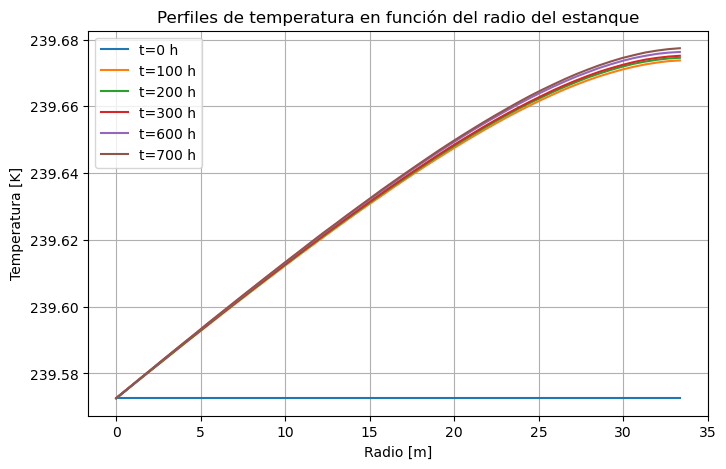

In [52]:
import matplotlib.pyplot as plt

# Tiempos a graficar (índices correspondientes)
time_indices = [0, 100, 200, 300, 600, 700]
z_grid = tanque.z_grid
r = (d_i / 2) * z_grid  # Radio en función de la fracción axial (z_grid va de 0 a 1)

plt.figure(figsize=(8, 5))
for idx in time_indices:
    plt.plot(r, sol.ys[idx, 1:], label=f"t={int(sol.ts[idx]//3600)} h")

plt.xlabel("Radio [m]")
plt.ylabel("Temperatura [K]")
plt.title("Perfiles de temperatura en función del radio del estanque")
plt.legend()
plt.grid(True)
plt.show()

In [103]:
# Re-ejecutar el código completo después del reinicio del entorno

import jax
import jax.numpy as jnp
from diffrax import diffeqsolve, ODETerm, Kvaerno5, SaveAt, PIDController, Kvaerno3, Tsit5  
from CoolProp.CoolProp import PropsSI

jax.config.update("jax_enable_x64", True)


class Cryogen:
    def __init__(self, fluid='ammonia', P=100000):
        self.fluid = fluid
        self.P = float(P)
        self.T_sat = jnp.array(PropsSI('T', 'P', P, 'Q', 0, fluid), dtype=jnp.float64)
        self.h_L   = jnp.array(PropsSI('H', 'P', P, 'Q', 0, fluid), dtype=jnp.float64)
        self.h_V   = jnp.array(PropsSI('H', 'P', P, 'Q', 1, fluid), dtype=jnp.float64)
        self.rho_L = jnp.array(PropsSI('D', 'P', P, 'Q', 0, fluid), dtype=jnp.float64)
        self.rho_V = jnp.array(PropsSI('D', 'P', P, 'Q', 1, fluid), dtype=jnp.float64)
        self.k_V   = jnp.array(PropsSI('L', 'P', P, 'Q', 1, fluid), dtype=jnp.float64)
        self.cp_V  = jnp.array(PropsSI('C', 'P', P, 'Q', 1, fluid), dtype=jnp.float64)


class Tank:
    def __init__(self, d_i, d_o, V, LF=0.95, cryogen=None):
        self.d_i           = jnp.array(d_i, dtype=jnp.float64)
        self.d_o           = jnp.array(d_o, dtype=jnp.float64)
        self.V             = jnp.array(V, dtype=jnp.float64)
        self.LF            = jnp.array(LF, dtype=jnp.float64)
        self.cryogen       = cryogen or Cryogen()
        self.z_grid        = jnp.linspace(0, 1, 50, dtype=jnp.float64)
        self.time_interval = 3600.0
        self.U_L           = jnp.array(0.08, dtype=jnp.float64)
        self.U_V           = jnp.array(0.08, dtype=jnp.float64)
        self.T_air         = jnp.array(298.15, dtype=jnp.float64)
        self.Q_b_fixed     = None
        self.Q_roof        = 0.0
        self.eta_w         = jnp.array(0.9, dtype=jnp.float64)


    def A_T(self):
        return jnp.pi * self.d_i ** 2 / 4

    def l(self):
        return self.V / self.A_T()


def make_params(tank):
    cryo = tank.cryogen
    return {
        "V":      tank.V,
        "d_i":    tank.d_i,
        "d_o":    tank.d_o,
        "LF":     tank.LF,
        "eta_w":  tank.eta_w,
        "T_air":  tank.T_air,
        "U_L":    tank.U_L,
        "U_V":    tank.U_V,
        "dz":     jnp.array(tank.z_grid[1] - tank.z_grid[0], dtype=jnp.float64),
        "z_grid": tank.z_grid,
        "T_sat":  cryo.T_sat,
        "h_L":    cryo.h_L,
        "h_V":    cryo.h_V,
        "rho_L":  cryo.rho_L,
        "rho_V":  cryo.rho_V,
        "k_V":    cryo.k_V,
        "cp_V":   cryo.cp_V
    }


@jax.jit
def sys_isobaric_jax(t, y, p):
    # Unpack variables
    V_L   = y[0]
    T_V   = y[1:]

    # Calculate parameters
    A_T   = jnp.pi * p["d_i"] ** 2 / 4
    l     = p["V"] / A_T
    l_dry = l * (1 - p['LF'])
    dz    = p["dz"] * l_dry

    # Areas
    A_V = jnp.pi * p["d_o"] * l * (1 - p['LF'])
    A_L = jnp.pi * p["d_o"] * l * p['LF']

    # Heat transfer calculations
    Q_Lin = p["U_L"] * A_L * (p["T_air"] - p["T_sat"])
    Q_VL  = p["k_V"] * A_T * (-3 * T_V[0] + 4 * T_V[1] - T_V[2]) / (2 * dz)
    Q_b   = p["U_L"] * A_T * (p["T_air"] - p["T_sat"])
    Q_wi  = p["U_V"] * A_V * p["eta_w"] * (p["T_air"] - jnp.mean(T_V))

    # Initial evaporation rate Kg/s
    BL_0 = (Q_Lin + Q_b + Q_wi) / (p["h_V"] - p["h_L"])
    
    # Advective and interface velocity
    v_z   = 4 * BL_0 / (p["rho_V"] * jnp.pi * p["d_i"] ** 2)
    v_int = v_z * (p["rho_V"] / p["rho_L"])

    # Vapour thermal diffusivity
    alpha = p["k_V"] / (p["rho_V"] * p["cp_V"])

    # Initialize derivatives
    dT = jnp.zeros_like(T_V)

    # Calculate space derivatives
    dT_dz   = (T_V[1:-1] - T_V[:-2]) / dz
    d2T_dz2 = (T_V[:-2] - 2 * T_V[1:-1] + T_V[2:]) / (dz ** 2)
    
    # Wall heating considering the wall heat partitioning.
    S_wall  = (4 * p["U_V"] * p["d_o"] / (p["d_i"] ** 2)) * (p["T_air"] - T_V[1:-1]) * (1 - p["eta_w"])

    # Update temperature derivatives
    dT = dT.at[1:-1].set(
        alpha * d2T_dz2 - (v_z - v_int) * dT_dz + (alpha/ p["k_V"]) * S_wall
    )

    # Boundary conditions
    dT = dT.at[0].set(0.0)
    dT = dT.at[-1].set((4 * dT[-2] - dT[-3]) / 3) # Neumann condition by default

    # Volume derivative
    dV = (-1 / p["rho_L"]) * (Q_Lin + Q_b + Q_wi + Q_VL) / (p["h_V"] - p["h_L"])

    return jnp.concatenate([jnp.array([dV], dtype=jnp.float64), dT])


def evaporate(tank, t_f):
    params = make_params(tank)

    VL_0 = jnp.array(tank.V * tank.LF, dtype=jnp.float64)
    Tv_0 = jnp.ones(len(tank.z_grid), dtype=jnp.float64) * tank.cryogen.T_sat
    IC   = jnp.concatenate([jnp.array([VL_0], dtype=jnp.float64), Tv_0])

    # Define the ODE term
    term   = ODETerm(sys_isobaric_jax)
    
    # Solve the ODE
    sol = diffeqsolve(
        term,
        solver=Tsit5(),
        t0=0,
        t1=t_f,
        dt0=0.01,
        y0=IC,
        args=params,
        saveat=SaveAt(ts=jnp.arange(0, t_f + 1, tank.time_interval)),
        max_steps=1000000,
        stepsize_controller=PIDController(rtol=1e-6, atol=1e-6),
    )
    return sol


In [104]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

#V_tank = 60000 # Tank volume / m^3
V_tank = 165000 # Tank volume / m^3

a = 0.7077
d_i = ((4 * V_tank)/(jnp.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.08 # 0.08 # W/m2/K
U_V = 0.08 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 100000 # Pa

# # Initialise cryogen
cryogen = Cryogen("ammonia")

tanque = Tank(d_i, d_o, V_tank, LF, cryogen)

In [107]:
sol = evaporate(tanque, 3600*720) 

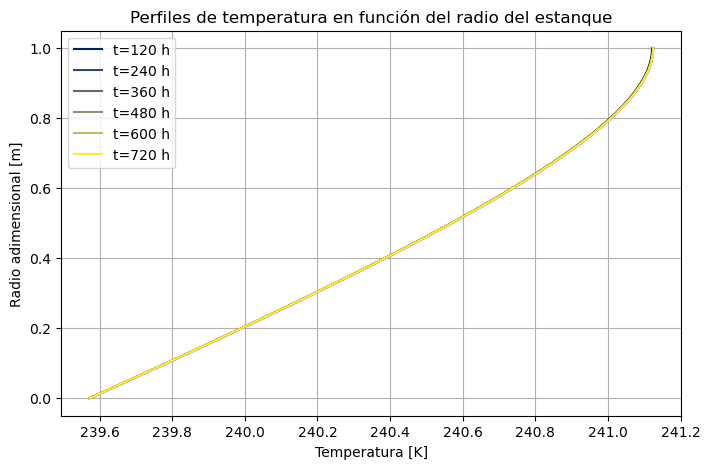

In [108]:
import matplotlib.pyplot as plt

# Tiempos a graficar (índices correspondientes)
time_indices = jnp.arange(0, sol.ts.shape[0], int(sol.ts.shape[0]/6) )
r = jnp.linspace(0, 1, len(tanque.z_grid))
plt.figure(figsize=(8, 5))
for i, idx in enumerate(time_indices[1:]):
    plt.plot(sol.ys[idx, 1:], r, label=f"t={int(sol.ts[idx]//3600)} h", color=plt.cm.cividis(i / (len(time_indices)-2)))
plt.xlabel("Temperatura [K]")
plt.ylabel("Radio adimensional [m]")
plt.title("Perfiles de temperatura en función del radio del estanque")
plt.legend()
plt.grid(True)
plt.show()


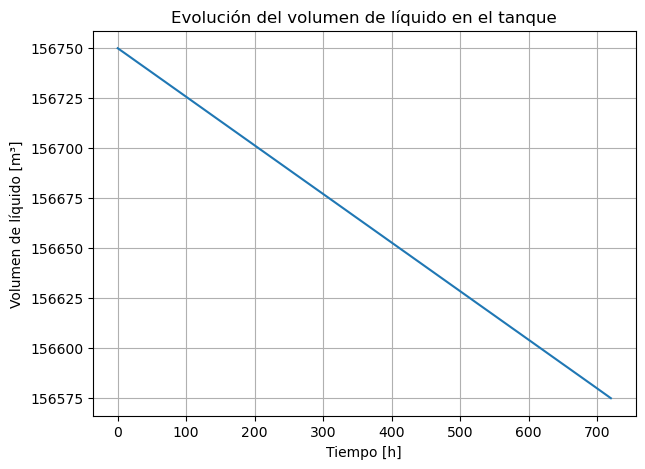

In [31]:
plt.figure(figsize=(7, 5))
plt.plot(sol.ts/3600, sol.ys[:, 0], label='Volumen de líquido')
plt.xlabel("Tiempo [h]")
plt.ylabel("Volumen de líquido [m³]")
plt.title("Evolución del volumen de líquido en el tanque")
plt.grid(True)
plt.show()